In [2]:
import pandas as pd
import geopandas as geopd
import numpy as np
# custom utils
from timeseries_utils import read_daily_timeseries_csv

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 300
plt.rcParams.update({'font.size': 18})
#plt.style.use('dark_background')
plt.rcParams['font.family'] = 'sans-serif'

In [3]:
@FuncFormatter
def date_formatter(x, pos):
    start_date = pd.to_datetime("1961-01-01")
    time = start_date + pd.Timedelta(days=x)
    #label = f"{time.year}-{time.month}"
    label = f"{time.year - start_date.year}"
    return label

In [5]:
src_path = '/media/iielse/T9/CAMELS-FI/data/timeseries-by-attribute/discharge_spec.csv'
data = read_daily_timeseries_csv(src_path)

In [6]:
data

,896,905,907,908,923,924,929,930,931,933,...,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
date,,,,,,,,,,,,,,,,,,,,,
1961-01-01,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-02,NaN,NaN,NaN,NaN,NaN,1.41,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-03,NaN,NaN,NaN,NaN,NaN,1.41,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-04,NaN,NaN,NaN,NaN,NaN,0.97,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-05,NaN,NaN,NaN,NaN,NaN,1.06,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,0.92,0.39,0.33,0.4,0.46,1.90,NaN,NaN,0.53,0.26,...,0.90,NaN,0.94,0.45,0.52,0.17,2.25,1.67,NaN,1.06
2023-12-28,0.90,0.38,0.32,0.4,0.45,1.70,NaN,NaN,0.53,0.26,...,1.10,NaN,0.94,0.41,0.50,0.17,2.23,1.29,NaN,1.08
2023-12-29,0.88,0.38,0.32,0.4,0.44,1.87,NaN,NaN,0.53,0.26,...,0.92,NaN,0.94,0.40,0.49,0.17,2.26,0.89,NaN,1.10


In [7]:
valid_counts = len(data) - data.isna().sum()

valid_counts = valid_counts.sort_values(ascending=False)

start_year = data.index[0].year
end_year = data.index[-1].year
year_count = end_year-start_year

gauge_count = len(data.columns)
xticks = [tick for tick in range(0, gauge_count + gauge_count//4, gauge_count//4)]
xlabels = [str(label) for label in range(0, 101, 25)]

cm_conversion = 1/2.54 

In [8]:
counts = pd.DataFrame(valid_counts)
counts = counts.rename(columns={0:'total_count'}, errors='raise')

decade_starts = [year for year in range(start_year, end_year - 10, 10)]
decade_ends = [year + 9 for year in decade_starts]
# changing years to strings so they work correctly with pandas.
decade_starts = list(map(str, decade_starts))
decade_ends = list(map(str, decade_ends))

decades = list(zip(decade_starts, decade_ends))

for decade in decades:
    decade_data = data.loc[decade[0]:decade[1]]
    # percentage valid
    decade_portion = ((len(decade_data) - decade_data.isna().sum()) / len(decade_data)) * 100

    """ sorting, and yes, this mixes the columns so that one row doesn't correspond to one catchment
    this is done so that the visualization will be readable. The visualization only shows percentages so this is okay
    """
    decade_portion = decade_portion.sort_values(ascending=False)
    
    name = f"{decade[0]}-{decade[1]}"
    #counts = counts.join(decade_portion)
    counts[name] = list(decade_portion)
    

In [9]:
decade_portion

3334    100.0
984     100.0
3257    100.0
1015    100.0
958     100.0
        ...  
1100      0.0
1104      0.0
981       0.0
1014      0.0
1009      0.0
Length: 320, dtype: float64

In [10]:
counts

,total_count,1961-1970,1971-1980,1981-1990,1991-2000,2001-2010,2011-2020
1401,23010,100.0,100.0,100.0,100.0,100.0,100.0
1015,23010,100.0,100.0,100.0,100.0,100.0,100.0
1388,23010,100.0,100.0,100.0,100.0,100.0,100.0
1382,23010,100.0,100.0,100.0,100.0,100.0,100.0
1341,23010,100.0,100.0,100.0,100.0,100.0,100.0
...,...,...,...,...,...,...,...
3605,2435,0.0,0.0,0.0,0.0,0.0,0.0
3155,2349,0.0,0.0,0.0,0.0,0.0,0.0
3308,2346,0.0,0.0,0.0,0.0,0.0,0.0
3727,2121,0.0,0.0,0.0,0.0,0.0,0.0


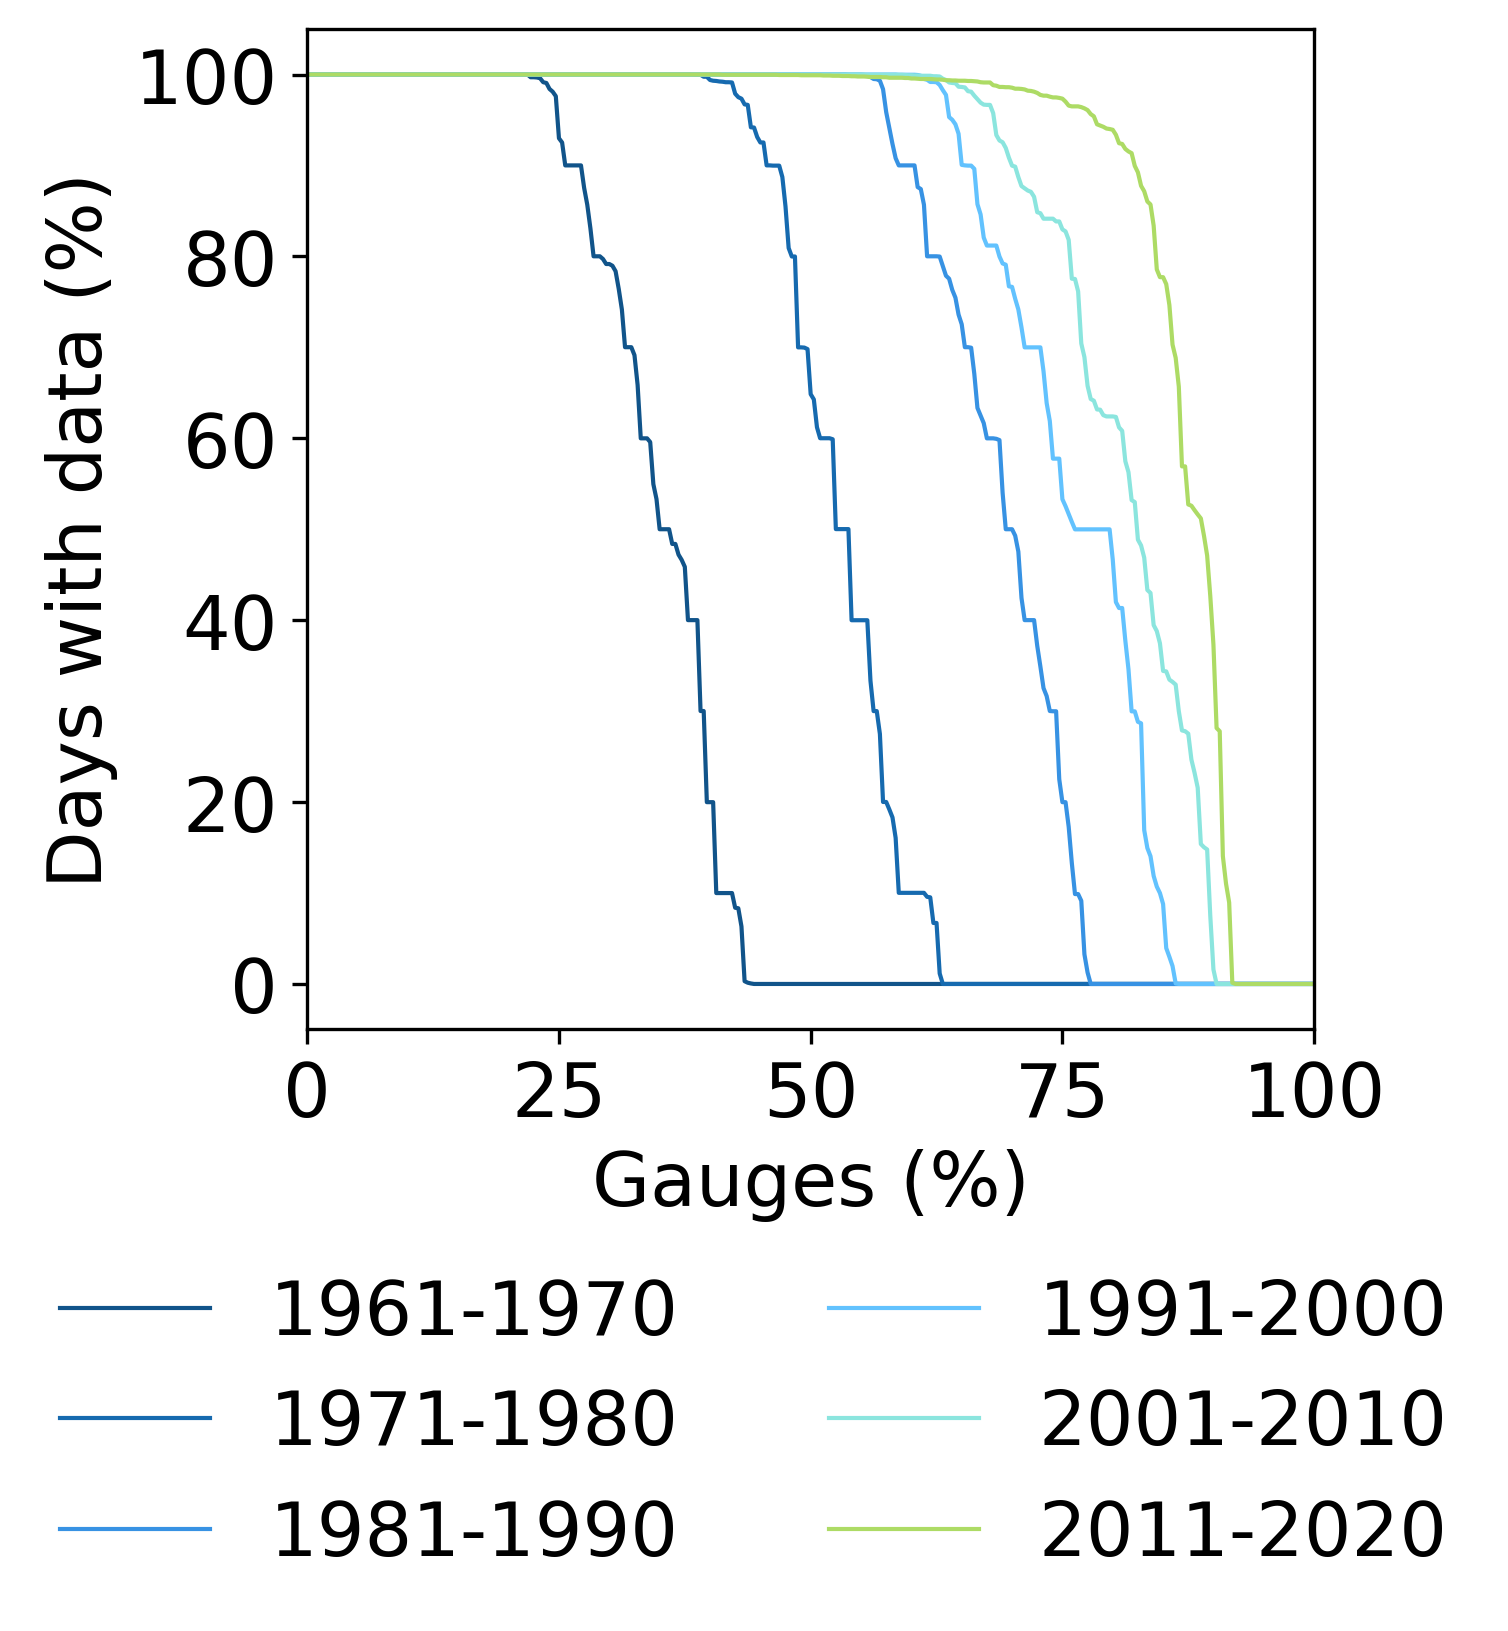

In [13]:
cmap = LinearSegmentedColormap.from_list('DIWA_6', ['#11548a', '#1770b8', '#4ca9ff', '#83e7fc', '#addb65'])

plt_data = counts.iloc[:, -6:]
plt_data = plt_data.reset_index(drop=True)
ax = plt_data.plot(legend=True, xlim=(0, gauge_count), cmap=cmap, figsize=(11*cm_conversion, 11*cm_conversion), linewidth=1)
legend = ax.legend(bbox_to_anchor=(1.2, -0.18), ncol=2)
legend.get_frame().set_edgecolor('#ffffff')
#ax.set_yticks(yticks, ylabels)
ax.set_ylabel('Days with data (%)')

ax.set_xticks(xticks, xlabels)
ax.set_xlabel('Gauges (%)')

dst_path = "/home/iielse/Documents/DIWA/visualizations/CAMELS-FI/figures/white/flow_availability.png"
plt.savefig(dst_path, dpi=300, transparent=True, bbox_inches='tight')

In [76]:
total = counts[['total_count']].copy()
total['timeseries_length_y'] = total['total_count'] / 365.25
total = total.round(decimals=2)

gauge_path = '/home/iielse/Documents/DIWA/data/omat digitoinnit/CAMELS-FI flow gauges.gpkg'
gauges = geopd.read_file(gauge_path, layer='attributes_v1')
gauges = gauges.set_index('Paikka_Id')
gauges = gauges.join(total['timeseries_length_y'])

In [77]:
total

,total_count,timeseries_length_y
924,23010,63.00
1186,23010,63.00
1158,23010,63.00
1107,23010,63.00
1097,23010,63.00
...,...,...
3605,2435,6.67
3155,2349,6.43
3308,2346,6.42
3727,2121,5.81


In [79]:
gauges

,Suure_Id,H_Kunta_Id,KuntaNimi,Nro,Nimi,KoordYkPohj,KoordYkIta,KoordPkPohj,KoordPkIta,KoordLat,...,KoordErTmPohj,KoordErTmIta,Jarvi_Id,JarviNro,JarviNimi,natural,water_region_code,water_region_name,geometry,timeseries_length_y
Paikka_Id,,,,,,,,,,,,,,,,,,,,,
896,2,260,Kitee,0201000,Kontturi,6879031,3674209,6874612,4516944,615838,...,6876149,673968,742,02.021.1.001,Kamarahkonlampi,1,B,Lakes,POINT (673968 6876149),46.00
905,2,541,Nurmes,0401110,"Saramojoki, Roukkajankoski",7062005,3603895,7060617,4455241,633837,...,7059048,603681,7860,04.471.1.001,Ylikylänjärvi,1,B,Lakes,POINT (603681 7059048),49.96
907,2,541,Nurmes,0401320,"Valtimonjoki, Nuolikoski",7068677,3587060,7068071,4438739,634228,...,7065717,586853,None,None,None,1,B,Lakes,POINT (586853 7065717),47.95
930,2,263,Kiuruvesi,0405440,Luupujoki,7064565,3491017,7064565,3491017,634054,...,7061606,490849,None,None,None,1,B,Lakes,POINT (490849 7061606),23.00
931,2,925,Vieremä,0405750,"Salahminjärvi, Salahmi",7078060,3496874,7078060,3496874,634810,...,7075096,496703,8683,04.541.1.001,Salahminjärvi,1,B,Lakes,POINT (496703 7075096),45.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,2,90,Heinävesi,0408650,"Juojärvi, Palokki",6940727,3583752,6940420,4429460,623341,...,6937819,583547,10259,04.711.1.002,Lapinpesä,0,B,Lakes,POINT (583582.115 6937848.657),63.00
964,2,420,Leppävirta,0409550,"Sorsavesi, Sorsakoski",6927384,3534192,6927384,3534192,622658,...,6924481,534007,4556,04.262.1.015,Välimeri,0,B,Lakes,POINT (534007 6924481),34.82
1369,2,698,Rovaniemi,6502350,Kaihua,7364650,3492410,7364650,3492410,662223,...,7361571,492240,34661,65.241.1.001,Iso-Kaihua,0,C,Lapland,POINT (492240 7361571),34.81


<Axes: >

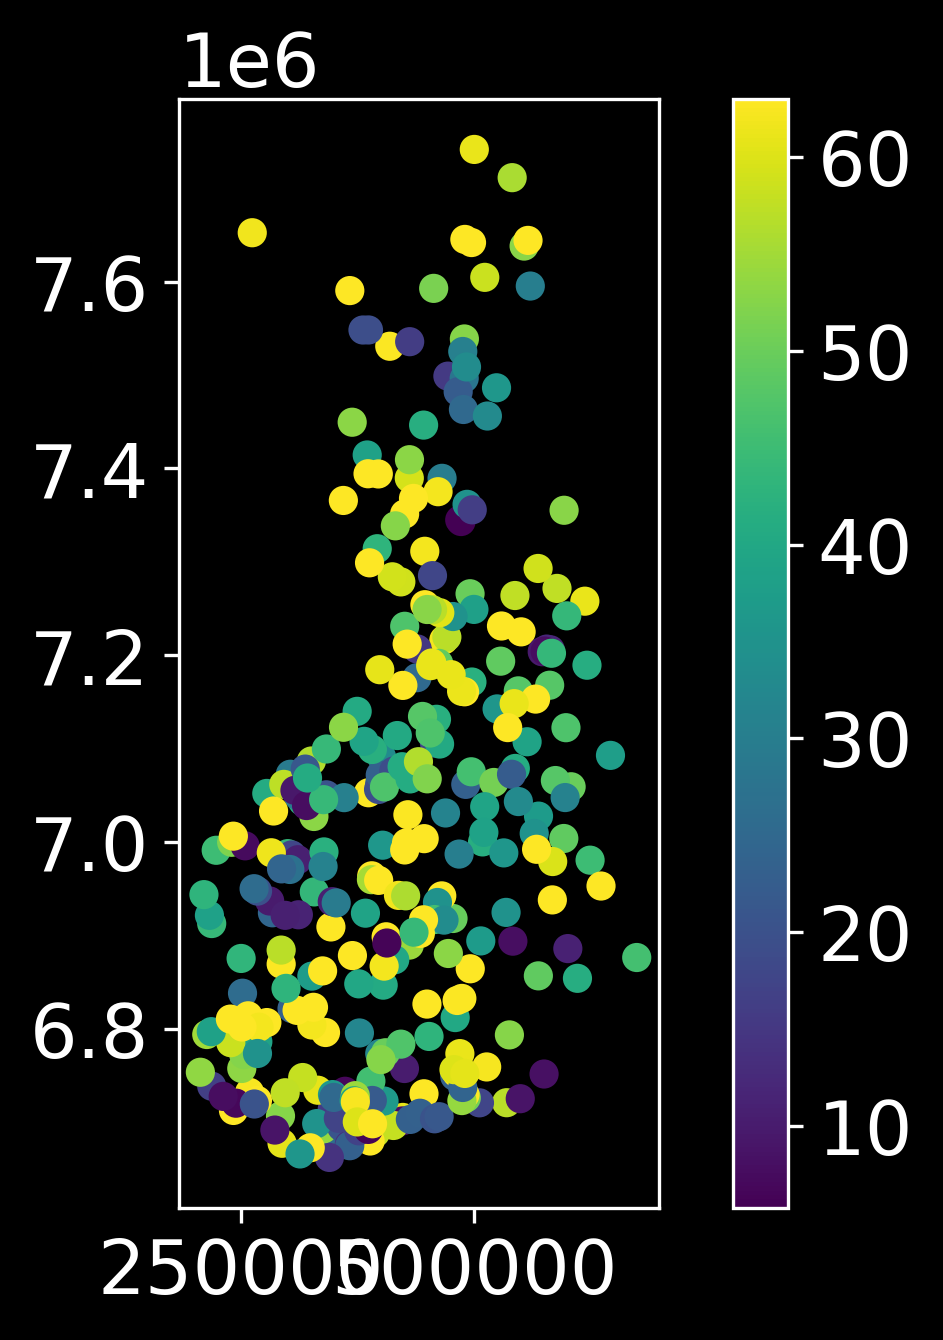

In [73]:
gauges.plot('timeseries_length', legend=True)

In [80]:
gauges.to_file(gauge_path, driver='GPKG', layer='attributes_v1')